<a href="https://colab.research.google.com/github/karthik-0211/Image-Captioning/blob/main/Image_Caption_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

File ‘Flickr8k_Dataset.zip’ already there; not retrieving.

File ‘Flickr8k_text.zip’ already there; not retrieving.

✅ Device: GPU
✅ Captions loaded: 8092
✅ Loaded cached features: 500
✅ Vocab size: 8831  Max length: 38


Encoding: 100%|██████████| 8092/8092 [00:02<00:00, 2871.59it/s]


✅ Data prepared: (29415, 2048) (29415, 38) (29415, 8831)


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 2048)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_20      │ (None, 38)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 256)       │    524,544 │ input_layer_19[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 38, 256)   │  2,260,736 │ input_layer_20[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_4         │ (None, 38)        │          0 │ input_layer_20[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_6 (LSTM)       │ (None, 256)       │    525,312 │ embedding_6[0][0… │
│                     │                   │            │ not_equal_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 256)       │          0 │ dropout_4[0][0],  │
│                     │                   │            │ lstm_6[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 256)       │     65,792 │ add_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 8831)      │  2,269,567 │ dense_19[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,645,951 (21.54 MB)

 Trainable params: 5,645,951 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - loss: 5.6837
Epoch 1: loss improved from inf to 5.06398, saving model to best_caption_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 74s 153ms/step - loss: 5.6823
Epoch 2/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 4.0935
Epoch 2: loss improved from 5.06398 to 4.03868, saving model to best_caption_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 68s 148ms/step - loss: 4.0934
Epoch 3/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - loss: 3.6918
Epoch 3: loss improved from 4.03868 to 3.66007, saving model to best_caption_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 68s 148ms/step - loss: 3.6918
Epoch 4/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - loss: 3.3855
Epoch 4: loss improved from 3.66007 to 3.40469, saving model to best_caption_model.keras
460/460 ━━━━━━━━━━━━━━━━━━━━ 68s 147ms/step - loss: 3.3855
Epoch 5/10
460/460 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step - loss: 3.1613
Epoch 5: loss improved from 3.40469 to 3.19643, saving model t

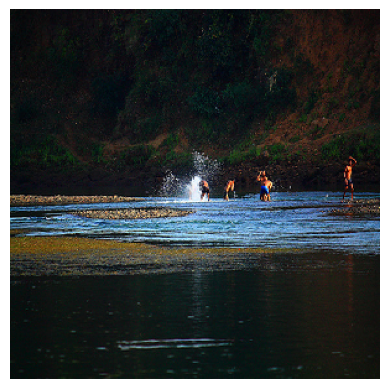

In [ ]:
# ===============================
# STEP 1: SETUP
# ===============================
!wget -nc https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip
!wget -nc https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip
!unzip -q -o Flickr8k_Dataset.zip
!unzip -q -o Flickr8k_text.zip

import os
import numpy as np
import string
import pickle
import random
import matplotlib.pyplot as plt
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Dropout, add
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from google.colab import files
from PIL import Image

print("✅ Device:", "GPU" if tf.config.list_physical_devices('GPU') else "CPU")

# Paths
images_path = "./Flicker8k_Dataset"
captions_path = "./Flickr8k.token.txt"

# ===============================
# STEP 2: LOAD CAPTIONS
# ===============================
def load_doc(filename):
    with open(filename, 'r') as f:
        return f.read()

doc = load_doc(captions_path)
captions = {}
for line in doc.strip().split("\n"):
    img, caption = line.split("\t")
    img_id = img.split(".")[0]
    caption = caption.lower().translate(str.maketrans("", "", string.punctuation))
    captions.setdefault(img_id, []).append("startseq " + caption + " endseq")

print("✅ Captions loaded:", len(captions))

# ===============================
# STEP 3: IMAGE FEATURES
# ===============================
inception = InceptionV3(weights="imagenet")
model_cnn = Model(inception.input, inception.layers[-2].output)

def extract_features(directory, limit=500):
    features = {}
    for i, img_name in enumerate(tqdm(os.listdir(directory))):
        if i >= limit: break
        filename = os.path.join(directory, img_name)
        image = load_img(filename, target_size=(299, 299))
        image = img_to_array(image)
        image = np.expand_dims(image, axis=0)
        image = preprocess_input(image)
        feature = model_cnn.predict(image, verbose=0)
        features[img_name.split(".")[0]] = feature.flatten()
    return features

# Load cached features if available
if os.path.exists("features_cache.pkl"):
    with open("features_cache.pkl", "rb") as f:
        features = pickle.load(f)
else:
    features = extract_features(images_path, limit=500)
    with open("features_cache.pkl", "wb") as f:
        pickle.dump(features, f)

print("✅ Loaded cached features:", len(features))

# ===============================
# STEP 4: TOKENIZER
# ===============================
all_captions = sum(captions.values(), [])
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)
vocab_size = len(tokenizer.word_index) + 1
max_length = max(len(c.split()) for c in all_captions)
print("✅ Vocab size:", vocab_size, " Max length:", max_length)

# ===============================
# STEP 5: DATA PREPARATION
# ===============================
X1, X2, y = [], [], []
for img_id, caps in tqdm(captions.items(), desc="Encoding"):
    feature = features.get(img_id)
    if feature is None: continue
    for cap in caps:
        seq = tokenizer.texts_to_sequences([cap])[0]
        for i in range(1, len(seq)):
            in_seq, out_seq = seq[:i], seq[i]
            in_seq = pad_sequences([in_seq], maxlen=max_length)[0]
            out_seq = to_categorical([out_seq], num_classes=vocab_size)[0]
            X1.append(feature)
            X2.append(in_seq)
            y.append(out_seq)

X1, X2, y = np.array(X1), np.array(X2), np.array(y)
print("✅ Data prepared:", X1.shape, X2.shape, y.shape)

# ===============================
# STEP 6: MODEL
# ===============================
inputs1 = Input(shape=(2048,))
fe = Dense(256, activation="relu")(inputs1)
fe = Dropout(0.5)(fe)

inputs2 = Input(shape=(max_length,))
se = Embedding(vocab_size, 256, mask_zero=True)(inputs2)
se = LSTM(256, recurrent_dropout=0.3)(se)

decoder = add([fe, se])
decoder = Dense(256, activation="relu")(decoder)
outputs = Dense(vocab_size, activation="softmax")(decoder)

model = Model([inputs1, inputs2], outputs)
model.compile(loss="categorical_crossentropy", optimizer="adam")
print(model.summary())

# ===============================
# STEP 7: TRAIN WITH CHECKPOINT
# ===============================
EPOCHS = 10
BATCH_SIZE = 64

checkpoint = ModelCheckpoint("best_caption_model.keras", monitor='loss', save_best_only=True, verbose=1)
early_stop = EarlyStopping(monitor='loss', patience=3, verbose=1)

history = model.fit([X1, X2], y, epochs=EPOCHS, batch_size=BATCH_SIZE,
                    callbacks=[checkpoint, early_stop], verbose=1)

# ===============================
# STEP 8: BEAM SEARCH CAPTION GENERATOR
# ===============================
def generate_caption_beam(photo, tokenizer, max_length, beam_width=3):
    sequences = [["startseq", 0.0]]
    for _ in range(max_length):
        all_candidates = []
        for seq, score in sequences:
            seq_encoded = tokenizer.texts_to_sequences([seq])[0]
            seq_encoded = pad_sequences([seq_encoded], maxlen=max_length)
            yhat = model.predict([photo, seq_encoded], verbose=0)[0]
            top_indices = np.argsort(yhat)[-beam_width:]
            for idx in top_indices:
                word = tokenizer.index_word.get(idx, "")
                if not word: continue
                candidate = [seq + " " + word, score - np.log(yhat[idx]+1e-10)]
                all_candidates.append(candidate)
        sequences = sorted(all_candidates, key=lambda t: t[1])[:beam_width]
    final_seq = sequences[0][0]
    final_seq = final_seq.replace("startseq", "").replace("endseq", "").strip()
    return final_seq

# ===============================
# STEP 9: TEST ON RANDOM IMAGE FROM DATASET
# ===============================
def test_random_image():
    test_id = random.choice(list(features.keys()))
    photo = features[test_id].reshape(1, 2048)  # Reshape
    caption = generate_caption_beam(photo, tokenizer, max_length, beam_width=3)
    print(f"🖼️ Image ID: {test_id}")
    print("📝 Generated Caption:", caption)

    # Display image
    img_path = os.path.join(images_path, test_id + ".jpg")
    img = load_img(img_path, target_size=(299, 299))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

# ===============================
# STEP 10: TEST ON UPLOADED IMAGE
# ===============================
def test_uploaded_image():
    uploaded = files.upload()
    for filename in uploaded.keys():
        img = load_img(filename, target_size=(299, 299))
        plt.imshow(img)
        plt.axis("off")
        plt.show()

        # preprocess for InceptionV3
        image = img_to_array(img)
        image = np.expand_dims(image, axis=0)
        image = preprocess_input(image)
        photo_feature = model_cnn.predict(image, verbose=0).reshape(1, 2048)

        caption = generate_caption_beam(photo_feature, tokenizer, max_length, beam_width=3)
        print("📝 Generated Caption:", caption)

# ===============================
# EXAMPLE USAGE
# ===============================
test_random_image()      # Test on random dataset image
# test_uploaded_image()    # Test on uploaded image
